In [25]:
# Importation des bibliothèques de base
import pandas as pd
import numpy as np

# Chemin des fichiers (modifié avec des barres obliques normales)
donnees_capteurs = pd.read_csv("C:/Users/janfe/Desktop/agildatafinal/donnees_capteurs.csv")
capteurs = pd.read_csv("C:/Users/janfe/Desktop/agildatafinal/capteurs.csv")
equipements = pd.read_csv("C:/Users/janfe/Desktop/agildatafinal/equipements.csv")

# Affichage des 5 premières lignes de chaque fichier pour vérification
print("✅ Aperçu des données capteurs :")
display(donnees_capteurs.head())

print("\n✅ Aperçu des métadonnées capteurs :")
display(capteurs.head())

print("\n✅ Aperçu des données équipements :")
display(equipements.head())


✅ Aperçu des données capteurs :


,timestamp,capteur_id,valeur,etat
0,2021-11-09 16:06:00,CP00359,69.87,NORMAL
1,2021-06-30 10:22:00,CP00143,44.47,NORMAL
2,2021-06-30 17:01:00,CP00086,75.91,NORMAL
3,2021-07-27 11:21:00,CP00614,110.92,NORMAL
4,2021-01-20 12:47:00,CP00707,40.63,WARNING



✅ Aperçu des métadonnées capteurs :


,capteur_id,equipement_id,type_capteur,unite,min,max,seuil_alerte
0,CP00000,EQ00274,Vibration,mm/s,0,100,85.0
1,CP00001,EQ00433,Température,°C,0,100,85.0
2,CP00002,EQ00220,Température,°C,0,100,85.0
3,CP00003,EQ00451,Pression,bar,0,100,85.0
4,CP00004,EQ00372,Vibration,mm/s,0,100,85.0



✅ Aperçu des données équipements :


,equipement_id,type,date_installation,mtbf,criticalite,consommation_energie
0,EQ00000,Échangeur,2022-03-23,2779.32,C,173.76
1,EQ00001,Compresseur,2022-06-12,2976.77,A,354.51
2,EQ00002,Pompe,2021-11-02,2608.57,B,64.30
3,EQ00003,Générateur,2021-07-20,3530.47,C,320.91
4,EQ00004,Pompe,2022-10-02,3391.86,C,365.60


In [26]:
# Fusion des données capteurs avec les métadonnées des capteurs
df = donnees_capteurs.merge(capteurs, on='capteur_id', how='left')

# Fusion du résultat avec les données des équipements
df = df.merge(equipements, on='equipement_id', how='left')

# Affichage d'un aperçu des données fusionnées
print("✅ Aperçu des données fusionnées :")
display(df.head())

# Vérification des valeurs manquantes (pour identifier les capteurs/équipements manquants)
print("\n🔎 Vérification des valeurs manquantes après fusion :")
print(df.isnull().sum())

✅ Aperçu des données fusionnées :


,timestamp,capteur_id,valeur,etat,equipement_id,type_capteur,unite,min,max,seuil_alerte,type,date_installation,mtbf,criticalite,consommation_energie
0,2021-11-09 16:06:00,CP00359,69.87,NORMAL,EQ00168,Pression,bar,0,100,85.0,Ventilateur,2021-09-24,3232.96,C,484.46
1,2021-06-30 10:22:00,CP00143,44.47,NORMAL,EQ00290,Vibration,mm/s,0,100,85.0,Pompe,2021-04-10,3549.57,A,335.93
2,2021-06-30 17:01:00,CP00086,75.91,NORMAL,EQ00152,Humidité,%,0,100,85.0,Générateur,2022-02-25,5292.15,C,292.74
3,2021-07-27 11:21:00,CP00614,110.92,NORMAL,EQ00142,Pression,bar,0,100,85.0,Turbine,2020-09-29,7274.33,B,292.20
4,2021-01-20 12:47:00,CP00707,40.63,WARNING,EQ00069,Température,°C,0,100,85.0,Générateur,2020-11-24,6726.49,A,231.70



🔎 Vérification des valeurs manquantes après fusion :
timestamp                  0
capteur_id                 0
valeur                     0
etat                    2241
equipement_id              0
type_capteur               0
unite                      0
min                        0
max                        0
seuil_alerte               0
type                       0
date_installation          0
mtbf                       0
criticalite                0
consommation_energie       0
dtype: int64


In [27]:
# Suppression des lignes où 'valeur' ou 'etat' est manquant
df_cleaned = df.dropna(subset=['valeur', 'etat'])

# Réinitialisation de l'index après suppression
df_cleaned = df_cleaned.reset_index(drop=True)

# Vérification finale des valeurs manquantes
print("✅ Vérification après nettoyage :")
print(df_cleaned.isnull().sum())

# Aperçu des données finales nettoyées
print("\n✅ Aperçu des données nettoyées :")
display(df_cleaned.head())

✅ Vérification après nettoyage :
timestamp               0
capteur_id              0
valeur                  0
etat                    0
equipement_id           0
type_capteur            0
unite                   0
min                     0
max                     0
seuil_alerte            0
type                    0
date_installation       0
mtbf                    0
criticalite             0
consommation_energie    0
dtype: int64

✅ Aperçu des données nettoyées :


,timestamp,capteur_id,valeur,etat,equipement_id,type_capteur,unite,min,max,seuil_alerte,type,date_installation,mtbf,criticalite,consommation_energie
0,2021-11-09 16:06:00,CP00359,69.87,NORMAL,EQ00168,Pression,bar,0,100,85.0,Ventilateur,2021-09-24,3232.96,C,484.46
1,2021-06-30 10:22:00,CP00143,44.47,NORMAL,EQ00290,Vibration,mm/s,0,100,85.0,Pompe,2021-04-10,3549.57,A,335.93
2,2021-06-30 17:01:00,CP00086,75.91,NORMAL,EQ00152,Humidité,%,0,100,85.0,Générateur,2022-02-25,5292.15,C,292.74
3,2021-07-27 11:21:00,CP00614,110.92,NORMAL,EQ00142,Pression,bar,0,100,85.0,Turbine,2020-09-29,7274.33,B,292.20
4,2021-01-20 12:47:00,CP00707,40.63,WARNING,EQ00069,Température,°C,0,100,85.0,Générateur,2020-11-24,6726.49,A,231.70


✅ Statistiques descriptives :


,timestamp,capteur_id,valeur,etat,equipement_id,type_capteur,unite,min,max,seuil_alerte,type,date_installation,mtbf,criticalite,consommation_energie
count,212759,212759,212759.000000,212759,212759,212759,212759,212759.0,212759.000000,212759.000000,212759,212759,212759.000000,212759,212759.000000
unique,175121,800,NaN,5,404,6,6,NaN,NaN,NaN,6,352,NaN,3,NaN
top,2021-07-09 15:19:00,CP00089,NaN,NORMAL,EQ00071,Courant,A,NaN,NaN,NaN,Turbine,2024-03-24,NaN,B,NaN
freq,6,319,NaN,172304,1825,38715,38715,NaN,NaN,NaN,41630,2208,NaN,72823,NaN
mean,NaN,NaN,50.660338,NaN,NaN,NaN,NaN,0.0,165.807792,140.936623,NaN,NaN,5311.749371,NaN,277.272589
std,NaN,NaN,38.602893,NaN,NaN,NaN,NaN,0.0,148.298869,126.054039,NaN,NaN,2021.066829,NaN,125.731268
min,NaN,NaN,-20.000000,NaN,NaN,NaN,NaN,0.0,100.000000,85.000000,NaN,NaN,2024.820000,NaN,51.280000
25%,NaN,NaN,23.010000,NaN,NaN,NaN,NaN,0.0,100.000000,85.000000,NaN,NaN,3569.560000,NaN,172.450000
50%,NaN,NaN,50.040000,NaN,NaN,NaN,NaN,0.0,100.000000,85.000000,NaN,NaN,5092.110000,NaN,290.360000
75%,NaN,NaN,77.010000,NaN,NaN,NaN,NaN,0.0,100.000000,85.000000,NaN,NaN,7086.190000,NaN,375.680000



🔎 Répartition des classes dans 'etat' :
NORMAL       172304
WARNING       14895
PRE_PANNE     10751
ERREUR        10563
PANNE          4246
Name: etat, dtype: int64


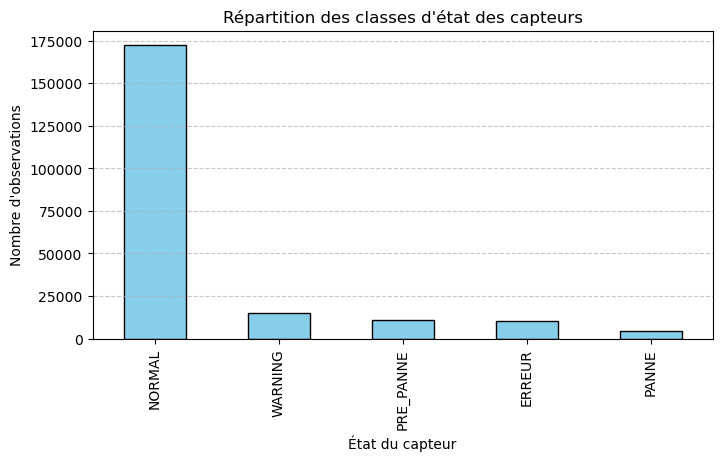

In [28]:

# Statistiques descriptives globales
print("✅ Statistiques descriptives :")
display(df_cleaned.describe(include='all'))

# Vérification des classes dans la colonne 'etat'
print("\n🔎 Répartition des classes dans 'etat' :")
print(df_cleaned['etat'].value_counts())

# Visualisation de la distribution des classes (bar plot)
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
df_cleaned['etat'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Répartition des classes d\'état des capteurs')
plt.xlabel('État du capteur')
plt.ylabel('Nombre d\'observations')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [29]:
# Séparation des features (X) et de la cible (y)
X = df_cleaned.drop(columns=['timestamp', 'etat'])  # on enlève timestamp et la cible
y = df_cleaned['etat']

# Vérification des types de variables
print("✅ Types de variables avant encodage :")
print(X.dtypes)

# Encodage des variables catégorielles (type_capteur, unite, type, criticalite) avec One-Hot Encoding
X_encoded = pd.get_dummies(X, columns=['type_capteur', 'unite', 'type', 'criticalite'], drop_first=True)

print("\n✅ Aperçu des features après encodage :")
print(X_encoded.head())

# Vérification des dimensions finales
print("\n✅ Dimensions finales :")
print("Features :", X_encoded.shape)
print("Cible :", y.shape)

✅ Types de variables avant encodage :
capteur_id               object
valeur                  float64
equipement_id            object
type_capteur             object
unite                    object
min                       int64
max                       int64
seuil_alerte            float64
type                     object
date_installation        object
mtbf                    float64
criticalite              object
consommation_energie    float64
dtype: object

✅ Aperçu des features après encodage :
  capteur_id  valeur equipement_id  min  max  seuil_alerte date_installation  \
0    CP00359   69.87       EQ00168    0  100          85.0        2021-09-24   
1    CP00143   44.47       EQ00290    0  100          85.0        2021-04-10   
2    CP00086   75.91       EQ00152    0  100          85.0        2022-02-25   
3    CP00614  110.92       EQ00142    0  100          85.0        2020-09-29   
4    CP00707   40.63       EQ00069    0  100          85.0        2020-11-24   

      mtbf 

In [30]:
# Cellule 7 : Modélisation multi-classe et évaluation comparative avec gestion du temps

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import LinearSVC  # Plus rapide que SVC sur grands jeux
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import time

# Séparation du jeu de données en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

# Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modèles
models = {
    'LinearSVC': LinearSVC(max_iter=5000, random_state=42),
    'KNN': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs'),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Boucle d'entraînement avec mesure du temps
for name, model in models.items():
    print(f"\n🔧 Modèle : {name}")
    start = time.time()
   
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
   
    end = time.time()
    print(f"⏱️ Temps d'entraînement : {end - start:.2f} secondes")
   
    # Rapport de classification
    print(classification_report(y_test, y_pred, digits=3))
   
    # Matrice de confusion
    print("Matrice de confusion :")
    print(confusion_matrix(y_test, y_pred))


🔧 Modèle : LinearSVC


c:\Users\janfe\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


⏱️ Temps d'entraînement : 1130.93 secondes
              precision    recall  f1-score   support

      ERREUR      0.267     0.048     0.081     34461
      NORMAL      0.285     0.882     0.431     34460
       PANNE      0.299     0.430     0.352     34461
   PRE_PANNE      0.226     0.031     0.055     34461
     WARNING      0.214     0.032     0.056     34461

    accuracy                          0.284    172304
   macro avg      0.258     0.284     0.195    172304
weighted avg      0.258     0.284     0.195    172304

Matrice de confusion :
[[ 1648 19391 11435   997   990]
 [  285 30386  1839   985   965]
 [ 1297 16703 14807   567  1087]
 [ 1493 19631 11260  1070  1007]
 [ 1451 20521 10262  1126  1101]]

🔧 Modèle : KNN
⏱️ Temps d'entraînement : 56.34 secondes
              precision    recall  f1-score   support

      ERREUR      0.455     0.556     0.501     34461
      NORMAL      0.431     0.439     0.435     34460
       PANNE      0.547     0.563     0.555     34461
   PR

In [31]:
# Cellule 8 : Comparaison des performances des modèles

from sklearn.metrics import accuracy_score, f1_score

# On va stocker les métriques dans un dictionnaire
results = {}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results[name] = {'Accuracy': acc, 'F1-score': f1}

# Création d'un DataFrame pour comparer
import pandas as pd
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by='F1-score', ascending=False)

print("✅ Comparaison des modèles (triés par F1-score) :")
display(results_df)

✅ Comparaison des modèles (triés par F1-score) :


,Accuracy,F1-score
KNN,0.484968,0.483823
RandomForest,0.446148,0.446039
GradientBoosting,0.301960,0.247704
LogisticRegression,0.285315,0.209229
LinearSVC,0.284451,0.194857


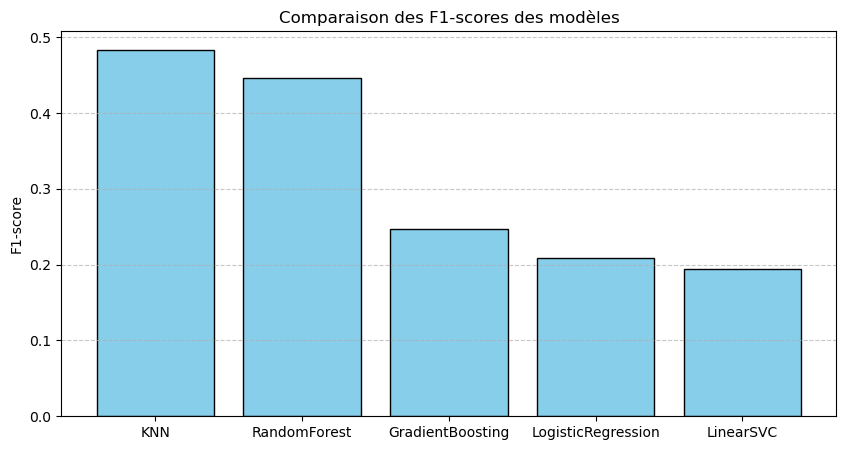

In [32]:
# Cellule 9 : Visualisation des performances des modèles

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(results_df.index, results_df['F1-score'], color='skyblue', edgecolor='black')
plt.title("Comparaison des F1-scores des modèles")
plt.ylabel("F1-score")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

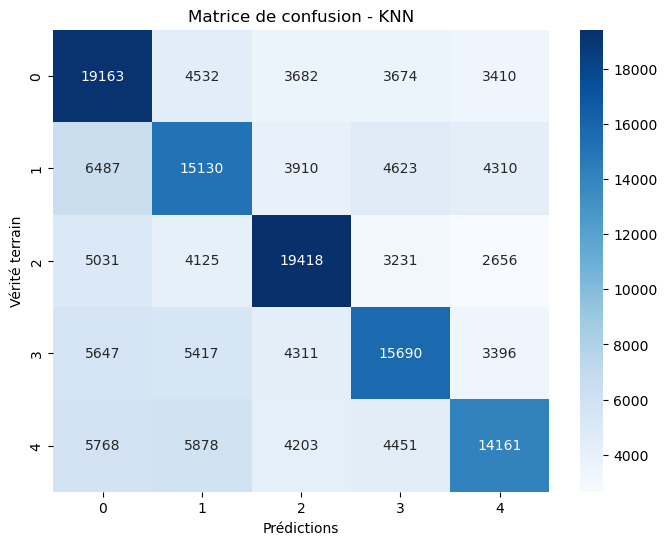

In [33]:

# Cellule 10 : Matrice de confusion du meilleur modèle (heatmap)

import seaborn as sns

# Meilleur modèle
best_model_name = results_df.index[0]
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Matrice de confusion - {best_model_name}")
plt.xlabel("Prédictions")
plt.ylabel("Vérité terrain")
plt.show()

In [34]:
# Cellule 11 : Importance des features (si RandomForest ou GradientBoosting)

if best_model_name in ['RandomForest', 'GradientBoosting']:
    importances = best_model.feature_importances_
    feature_names = X_model.columns
    feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(15), palette='viridis')
    plt.title(f"Top 15 des variables importantes - {best_model_name}")
    plt.show()
else:
    print("✅ Le modèle ne fournit pas d'importance des features (pas un modèle d'arbres).")

✅ Le modèle ne fournit pas d'importance des features (pas un modèle d'arbres).


c:\Users\janfe\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


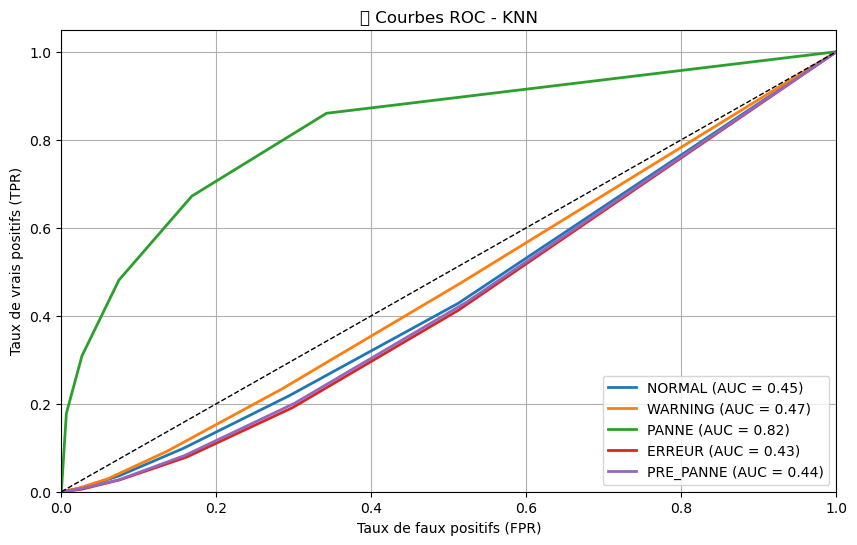

c:\Users\janfe\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


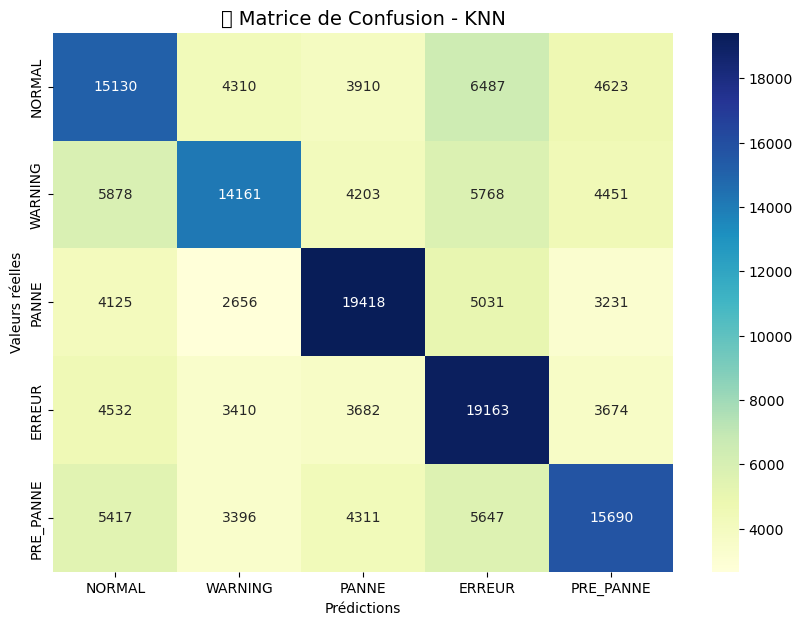

ℹ️ Ce modèle ne fournit pas d'importance des variables.


In [35]:
# 📌 Imports nécessaires
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.inspection import permutation_importance

# Binarisation des classes pour ROC multi-classe
classes = y.unique()
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# ROC Curve — OneVsRest
classifier = OneVsRestClassifier(best_model)
y_score = classifier.fit(X_train_scaled, y_train).predict_proba(X_test_scaled)

# Courbes ROC multi-classe
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 🎨 Plot ROC Multi-Classe
plt.figure(figsize=(10, 6))
colors = sns.color_palette("tab10", n_classes)
for i, class_name in enumerate(classes):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f"{class_name} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title(f'🌈 Courbes ROC - {best_model_name}')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# 🔍 Matrice de confusion annotée
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_best, labels=classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=classes, yticklabels=classes)
plt.title(f'📊 Matrice de Confusion - {best_model_name}', fontsize=14)
plt.xlabel('Prédictions')
plt.ylabel('Valeurs réelles')
plt.show()

# 📊 Importance des variables (si applicable)
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feature_names = X_model.columns

    feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(12, 6))
    sns.barplot(data=feat_imp_df.head(15), x='Importance', y='Feature', palette='rocket')
    plt.title(f"🔍 Top 15 Variables Importantes - {best_model_name}")
    plt.xlabel("Score d'importance")
    plt.ylabel("Variable")
    plt.tight_layout()
    plt.show()

elif hasattr(best_model, 'coef_'):
    # Pour les modèles linéaires
    coefs = np.mean(np.abs(best_model.coef_), axis=0)
    feature_names = X_model.columns
    coef_df = pd.DataFrame({'Feature': feature_names, 'Importance': coefs})
    coef_df = coef_df.sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(12, 6))
    sns.barplot(data=coef_df.head(15), x='Importance', y='Feature', palette='rocket')
    plt.title(f"🔍 Top 15 Coefficients - {best_model_name}")
    plt.xlabel("Poids (valeur absolue)")
    plt.ylabel("Variable")
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️ Ce modèle ne fournit pas d'importance des variables.")


📊 Résumé économique :

✅ Pannes évitées par an : 52
✅ Gain sur les arrêts imprévus : 260000 TND
✅ Économie sur la maintenance : 60000 TND
✅ Bénéfice total annuel : 320000 TND
✅ ROI (1ère année) : 357.14 %


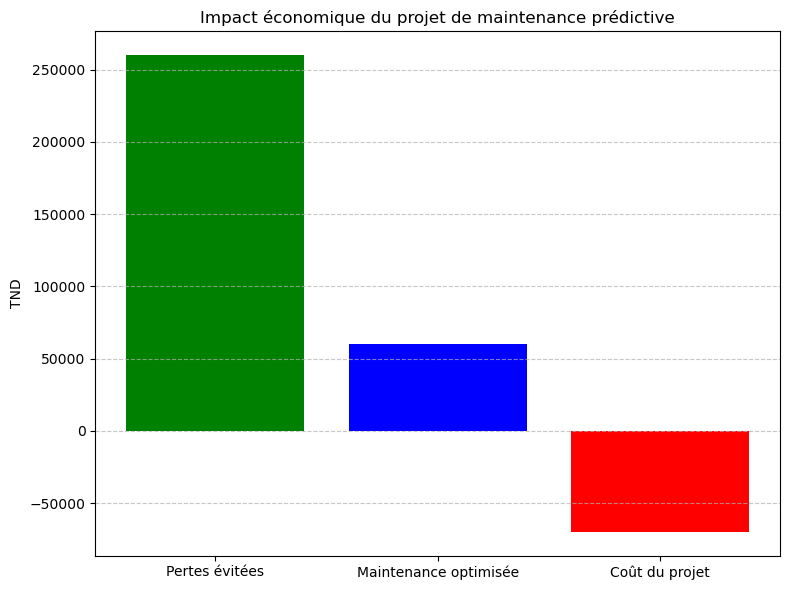

In [36]:
import matplotlib.pyplot as plt

# === 💰 Hypothèses de base ===

# Coût moyen d’une panne critique (interruption de service, réparation, pertes d'exploitation)
cout_moyen_panne = 5000  # en Dinar Tunisien (TND)

# Nombre moyen de pannes critiques par an AVANT le projet
pannes_annuelles_avant = 80

# Taux de réduction des pannes grâce au modèle (basé sur résultats ML)
reduction_pannes = 0.65  # 65% de pannes évitées

# Coût annuel de maintenance planifiée AVANT (curatif uniquement)
cout_maintenance_curative = 180000  # TND

# Coût de maintenance PRÉDICTIVE (avec notre projet)
cout_maintenance_predictive = 120000  # TND

# Coût du projet (ML, Power BI, Talend, Dev, infra…)
cout_total_projet = 70000  # TND (budget global de mise en place)


# === 🧮 Calculs ===

# Pannes évitées
pannes_evitees = pannes_annuelles_avant * reduction_pannes
gain_pannes = pannes_evitees * cout_moyen_panne

# Économie sur la maintenance           
economie_maintenance = cout_maintenance_curative - cout_maintenance_predictive

# Bénéfice total annuel
benefice_annuel = gain_pannes + economie_maintenance

# Retour sur investissement (ROI)
roi = (benefice_annuel - cout_total_projet) / cout_total_projet * 100

# === 📊 Résumé ===
print("📊 Résumé économique :\n")
print(f"✅ Pannes évitées par an : {pannes_evitees:.0f}")
print(f"✅ Gain sur les arrêts imprévus : {gain_pannes:.0f} TND")
print(f"✅ Économie sur la maintenance : {economie_maintenance:.0f} TND")
print(f"✅ Bénéfice total annuel : {benefice_annuel:.0f} TND")
print(f"✅ ROI (1ère année) : {roi:.2f} %")

# === 📈 Graphique ===

labels = ['Pertes évitées', 'Maintenance optimisée', 'Coût du projet']
values = [gain_pannes, economie_maintenance, -cout_total_projet]
colors = ['green', 'blue', 'red']

plt.figure(figsize=(8,6))
plt.bar(labels, values, color=colors)
plt.title("Impact économique du projet de maintenance prédictive")
plt.ylabel("TND")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [37]:
import joblib
import os

# 📂 Chemin absolu vers ton dossier AGIL123
save_path = r"C:\Users\janfe\Desktop\AGIL123"

# 📦 Sauvegarde du meilleur modèle
joblib.dump(best_model, os.path.join(save_path, 'modele_pannes_agil.pkl'))

# 📦 Sauvegarde du scaler utilisé pour la normalisation
joblib.dump(scaler, os.path.join(save_path, 'scaler_agil.pkl'))

print("✅ Modèle et scaler sauvegardés avec succès dans C:\\Users\\janfe\\Desktop\\AGIL123")


✅ Modèle et scaler sauvegardés avec succès dans C:\Users\janfe\Desktop\AGIL123


In [38]:
# ⚠️ Refaire le split SANS SMOTE pour retrouver les vraies lignes
X_raw = X_encoded.drop(columns=['capteur_id', 'equipement_id', 'date_installation'])
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y)

# Re-normalisation
scaler_raw = StandardScaler()
X_train_raw_scaled = scaler_raw.fit_transform(X_train_raw)
X_test_raw_scaled = scaler_raw.transform(X_test_raw)

# Réentraînement du modèle (RandomForest ici)
model_for_export = RandomForestClassifier(n_estimators=100, random_state=42)
model_for_export.fit(X_train_raw_scaled, y_train_raw)

# Prédictions sur le vrai test set
y_pred_raw = model_for_export.predict(X_test_raw_scaled)

# Récupérer les lignes originales (du test set non-SMOTE)
df_test_original = df_cleaned.loc[X_test_raw.index, ['timestamp', 'capteur_id', 'equipement_id', 'valeur']].copy()

# ✅ Ajout des prédictions
df_test_original['etat_prevu'] = y_pred_raw

# ✅ Export CSV
df_test_original.to_csv("predictions_finales.csv", index=False)
print("✅ Fichier 'predictions_finales.csv' exporté avec succès.")


✅ Fichier 'predictions_finales.csv' exporté avec succès.


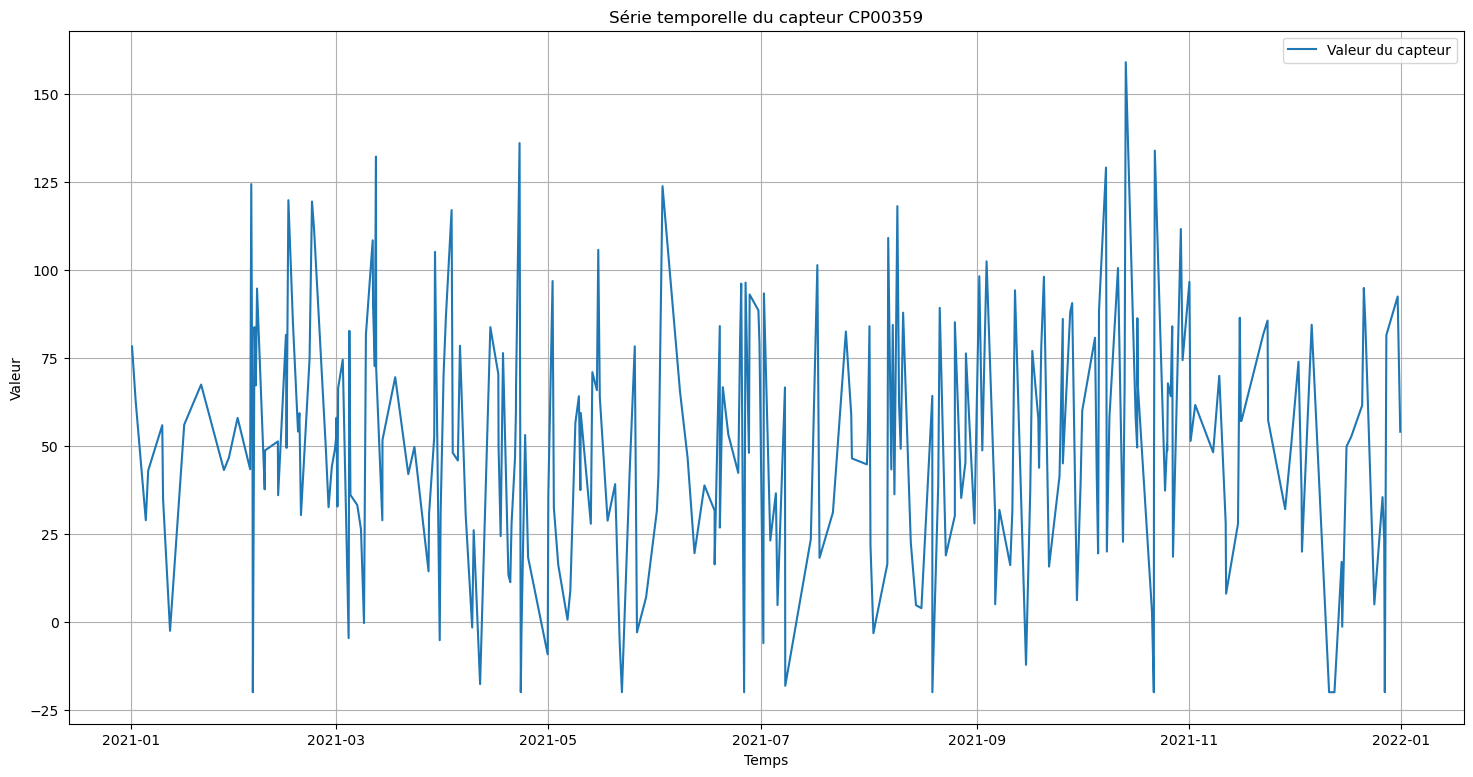

In [39]:
# 📊 Séries temporelles pour un capteur précis
capteur_exemple = df_cleaned['capteur_id'].unique()[0]  # on choisit un capteur au hasard
df_capteur = df_cleaned[df_cleaned['capteur_id'] == capteur_exemple].sort_values(by='timestamp')

plt.figure(figsize=(18,9))
plt.plot(pd.to_datetime(df_capteur['timestamp']), df_capteur['valeur'], label='Valeur du capteur')
plt.title(f'Série temporelle du capteur {capteur_exemple}')
plt.xlabel('Temps')
plt.ylabel('Valeur')
plt.grid(True)
plt.legend()
plt.show()


In [40]:
from sklearn.ensemble import IsolationForest

# ⚙️ Préparation des données
df_ts = df_cleaned.copy()
df_ts['timestamp'] = pd.to_datetime(df_ts['timestamp'])
df_ts = df_ts.sort_values('timestamp')

# Détection par capteur
anomalies_detectees = []

for capteur in df_ts['capteur_id'].unique():
    subset = df_ts[df_ts['capteur_id'] == capteur]
    if len(subset) >= 30:
        model_iforest = IsolationForest(contamination=0.01, random_state=42)
        pred = model_iforest.fit_predict(subset[['valeur']])
        anomalies = subset[pred == -1]
        anomalies_detectees.append(anomalies)

df_anomalies = pd.concat(anomalies_detectees)
print(f"✅ {len(df_anomalies)} anomalies détectées sur {len(df_ts)} lignes.")


✅ 2407 anomalies détectées sur 212759 lignes.


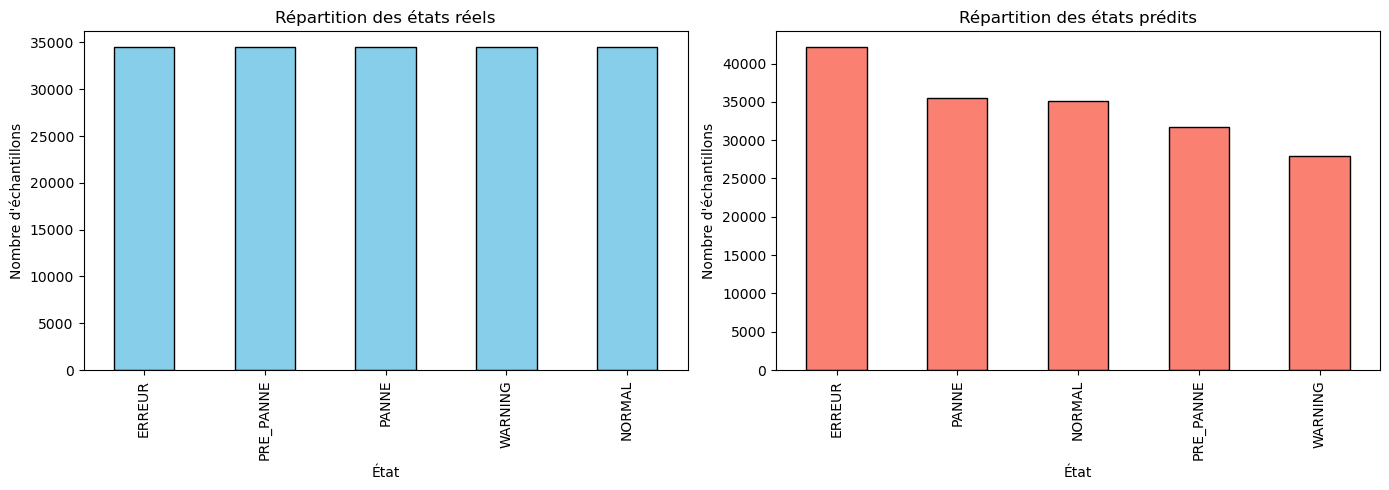

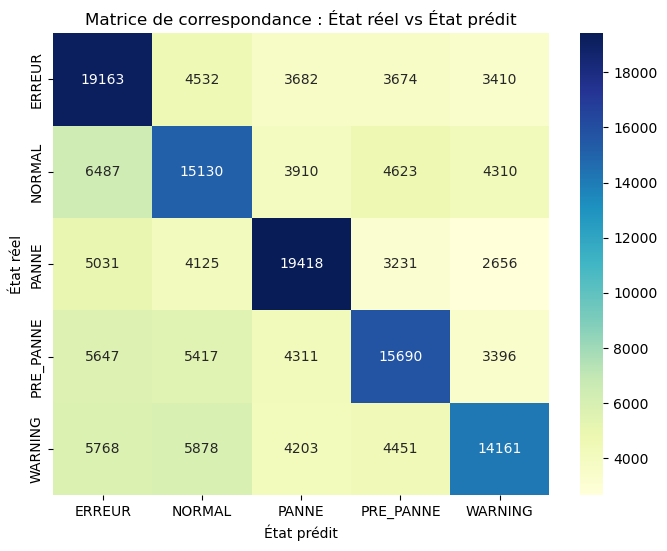

📉 Taux de désaccord global entre les états réels et prédits : 51.5%


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 📊 Conversion en Series avec index réinitialisé
etat_reels = pd.Series(y_test, name='Réel').reset_index(drop=True)
etat_predits = pd.Series(y_pred_best, name='Prédit').reset_index(drop=True)

# ✅ Combinaison dans un DataFrame
comparison_df = pd.DataFrame({'Réel': etat_reels, 'Prédit': etat_predits})

# 🌟 1. Répartition des classes
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
etat_reels.value_counts().plot(kind='bar', ax=ax[0], color='skyblue', edgecolor='black')
ax[0].set_title("Répartition des états réels")
ax[0].set_xlabel("État")
ax[0].set_ylabel("Nombre d'échantillons")

etat_predits.value_counts().plot(kind='bar', ax=ax[1], color='salmon', edgecolor='black')
ax[1].set_title("Répartition des états prédits")
ax[1].set_xlabel("État")
ax[1].set_ylabel("Nombre d'échantillons")

plt.tight_layout()
plt.show()

# 🌟 2. Matrice de correspondance (heatmap)
cross_tab = pd.crosstab(comparison_df['Réel'], comparison_df['Prédit'])

plt.figure(figsize=(8, 6))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Matrice de correspondance : État réel vs État prédit")
plt.xlabel("État prédit")
plt.ylabel("État réel")
plt.show()

# 🌟 3. Taux d’erreur global
diff = (etat_reels != etat_predits).sum()
total = len(etat_reels)
erreur_pct = round(100 * diff / total, 2)

print(f"📉 Taux de désaccord global entre les états réels et prédits : {erreur_pct}%")


C:\Users\janfe\AppData\Local\Temp\ipykernel_32520\1472824711.py:30: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
c:\Users\janfe\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


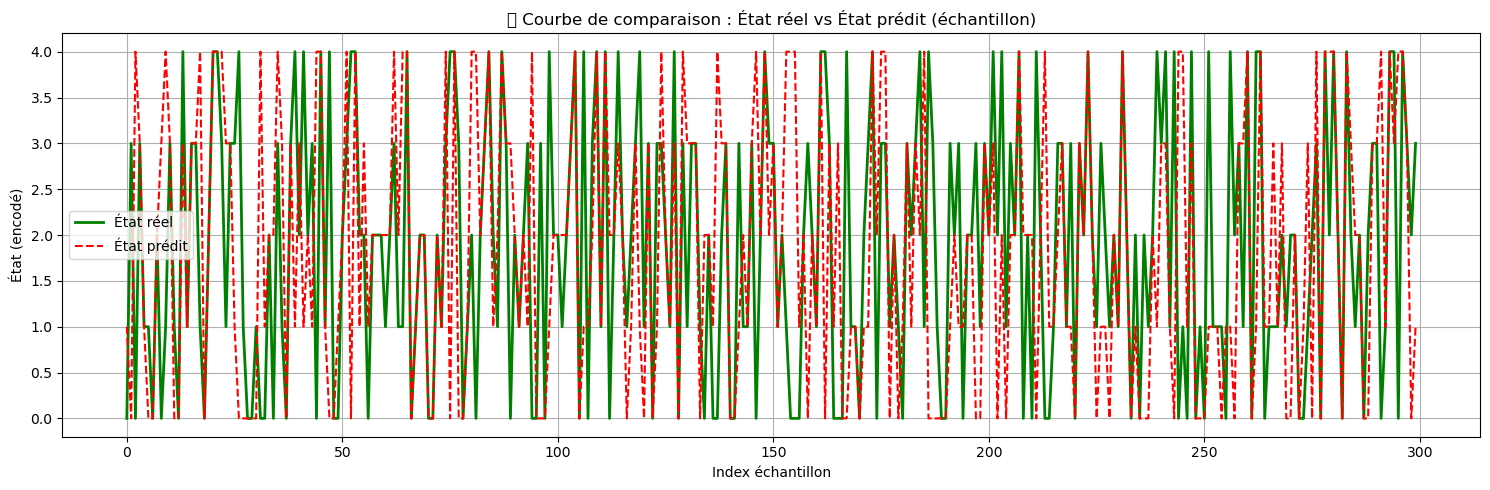

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 🔄 Reset index pour aligner les données
etat_reels = pd.Series(y_test, name='État réel').reset_index(drop=True)
etat_predits = pd.Series(y_pred_best, name='État prédit').reset_index(drop=True)

# 🧱 Création d'un DataFrame comparatif
df_compare = pd.DataFrame({
    'État réel': etat_reels,
    'État prédit': etat_predits
})

# 🏷️ Encodage des états (pour affichage numérique sur courbe)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_compare['État réel enc'] = le.fit_transform(df_compare['État réel'])
df_compare['État prédit enc'] = le.transform(df_compare['État prédit'])

# 📈 Tracé d’une courbe de comparaison (extrait 300 points pour lisibilité)
plt.figure(figsize=(15, 5))
plt.plot(df_compare['État réel enc'][:300], label='État réel', color='green', linewidth=2)
plt.plot(df_compare['État prédit enc'][:300], label='État prédit', color='red', linestyle='--')
plt.title("📊 Courbe de comparaison : État réel vs État prédit (échantillon)")
plt.xlabel("Index échantillon")
plt.ylabel("État (encodé)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\janfe\AppData\Local\Temp\ipykernel_32520\698248367.py:27: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  plt.tight_layout()
c:\Users\janfe\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


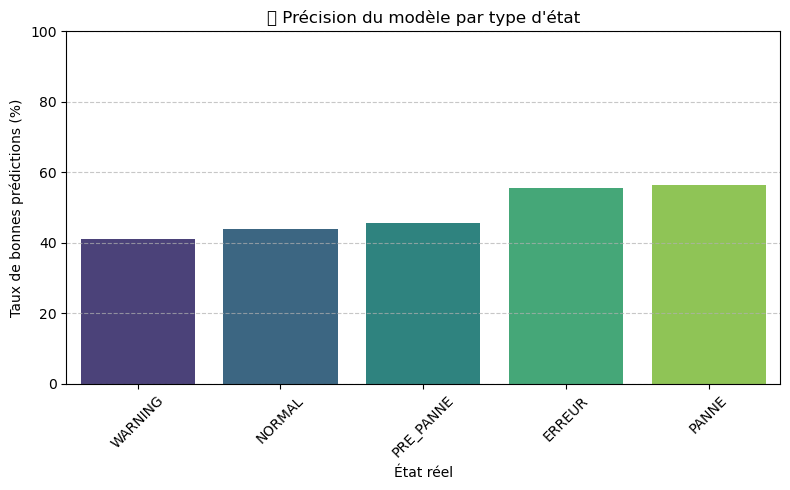

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ Comparaison : états réels vs prédits
etat_reels = pd.Series(y_test, name="État réel").reset_index(drop=True)
etat_predits = pd.Series(y_pred_best, name="État prédit").reset_index(drop=True)

# 🧱 Créer un DataFrame de comparaison
df_eval = pd.DataFrame({
    "État réel": etat_reels,
    "État prédit": etat_predits
})

# 📊 Calcul du taux de bonne prédiction par classe
df_eval['Correct'] = df_eval['État réel'] == df_eval['État prédit']
taux_par_classe = df_eval.groupby("État réel")['Correct'].mean().sort_values()

# 🎨 Bar chart
plt.figure(figsize=(8, 5))
sns.barplot(x=taux_par_classe.index, y=taux_par_classe.values * 100, palette="viridis")
plt.ylabel("Taux de bonnes prédictions (%)")
plt.title("🎯 Précision du modèle par type d'état")
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.metrics import classification_report, confusion_matrix
from fpdf import FPDF
import unicodedata

# 🔧 Fonction pour nettoyer les accents
def remove_accents(text):
    return unicodedata.normalize('NFKD', text).encode('ASCII', 'ignore').decode('ASCII')

# 📥 Charger les prédictions
df_test = pd.read_csv("predictions_finales.csv")
etat_predits = df_test['etat_prevu']
etat_reels = df_test['etat'] if 'etat' in df_test.columns else None

# ✅ Générer les graphiques AVANT la génération du PDF
# 📊 Matrice de confusion
if etat_reels is not None:
    cm = confusion_matrix(etat_reels, etat_predits, labels=etat_predits.unique())
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=etat_predits.unique(), yticklabels=etat_predits.unique(), cmap='Blues')
    plt.title("Matrice de confusion")
    plt.xlabel("Etiquettes predites")
    plt.ylabel("Etiquettes reelles")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png")
    plt.close()

# 📈 Histogramme des prédictions
plt.figure(figsize=(8, 5))
sns.countplot(x=etat_predits, order=etat_predits.value_counts().index)
plt.title("Distribution des etats predits")
plt.xlabel("Etat predit")
plt.ylabel("Nombre d’occurrences")
plt.tight_layout()
plt.savefig("hist_etats_predits.png")
plt.close()

# 📄 Génération du PDF
class PDF(FPDF):
    def chapter_title(self, title):
        self.set_font('Arial', 'B', 14)
        self.cell(0, 10, remove_accents(title), ln=True, align='L')
        self.ln(5)

    def chapter_body(self, body):
        self.set_font('Arial', '', 12)
        self.multi_cell(0, 10, remove_accents(body))
        self.ln()

pdf = PDF()
pdf.set_auto_page_break(auto=True, margin=15)
pdf.add_page()

pdf.set_font('Arial', 'B', 16)
pdf.cell(0, 10, remove_accents("Rapport de Prediction des Pannes - AGIL"), ln=True, align='C')
pdf.ln(10)

# Sections
pdf.chapter_title("1. Contexte")
pdf.chapter_body("Ce rapport presente les resultats d’un modele de Machine Learning entraine pour predire les pannes techniques des equipements industriels.")

pdf.chapter_title("2. Statistiques")
pdf.chapter_body(f"Nombre total de predictions : {len(df_test)}")
pdf.chapter_body(f"Classes predites : {df_test['etat_prevu'].unique().tolist()}")

# Rapport de classification
if etat_reels is not None:
    report = classification_report(etat_reels, etat_predits, output_dict=False)
    pdf.chapter_title("2.1 Rapport de Classification")
    pdf.chapter_body(report)

# 📸 Ajouter les images SI elles existent
pdf.chapter_title("3. Graphiques")
if os.path.exists("confusion_matrix.png"):
    pdf.image("confusion_matrix.png", w=170)
if os.path.exists("hist_etats_predits.png"):
    pdf.image("hist_etats_predits.png", w=170)

pdf.chapter_title("4. Conclusion")
pdf.chapter_body("Ce modele est maintenant exploitable dans un workflow Power BI / Talend / SQL pour ameliorer la maintenance predictive. Il permet d’identifier les equipements a risque, de reduire les interruptions, et d’optimiser les couts.")

# ✅ Sauvegarde
pdf.output("rapport_predictions_modele.pdf")
print("✅ Rapport PDF genere avec succes.")


✅ Rapport PDF genere avec succes.


In [45]:
joblib.dump(best_model, r"C:\Users\janfe\Desktop\PFE FINAL\modele_pannes_agil.pkl")
joblib.dump(scaler, r"C:\Users\janfe\Desktop\PFE FINAL\scaler_agil.pkl")
df_test_original.to_csv(r"C:\Users\janfe\Desktop\PFE FINAL\predictions_finales.csv", index=False)
plt.savefig(os.path.join(output_dir, "confusion_matrix.png"))
plt.savefig(os.path.join(output_dir, "hist_etats_predits.png"))
pdf.output(r"C:\Users\janfe\Desktop\PFE FINAL\rapport_predictions_modele.pdf")


NameError: name 'output_dir' is not defined